## Работа Максимовой Алины 6133-010402D
Импортируем необходимые библиотеки:

In [76]:
import numpy as np
import time
import math
import pandas as pd
from numba import cuda
import matplotlib.pyplot as plt

Проверка подключения к GPU:

In [77]:
# Проверка GPU
assert cuda.is_available(), "CUDA GPU не найдено"

В отдельные функции вынесем логику перемножения матриц на CPU и GPU:

In [78]:
def mult_matr_cpu(A, B):
    # Создаем результирующую матрицу C нужного размера, заполненную нулями
    # Количество строк от A, количество столбцов от B
    C = np.zeros((A.shape[0], B.shape[1]), dtype=np.float32)

    start_time = time.time()

    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            temp_sum = 0.0  # Переменная для накопления скалярного произведения

            for k in range(A.shape[1]):
                temp_sum += A[i, k] * B[k, j] # суммируем произведения элементов строки A и столбца B
            C[i, j] = temp_sum

    end_time = time.time()
    return C, end_time - start_time # Возвращаем готовую матрицу и затраченное время (разница между end и start)

@cuda.jit # Декоратор, который компилирует функцию для выполнения на GPU (CUDA)
def mat_mul(A, B, C):
    # Автоматически определяем глобальные индексы потока (thread)
    # для двумерной сетки (соответствуют координатам i и j в матрице)
    i, j = cuda.grid(2)

    # Проверка границ: выполняем расчет только если индексы
    # не выходят за пределы размеров результирующей матрицы
    if i < A.shape[0] and j < B.shape[1]:
        temp_sum = 0
        for k in range(A.shape[1]):
            temp_sum += A[i, k] * B[k, j]
        C[i, j] = temp_sum

def mult_matr_gpu(A, B, num_runs=3):
    # Копируем входные матрицы из оперативной памяти в память видеокарты
    A_device = cuda.to_device(A)
    B_device = cuda.to_device(B)

    # Резервируем в памяти GPU место под результирующую матрицу C нужного размера
    C_device = cuda.device_array((A.shape[0], B.shape[1]), dtype=np.float32)

    # Настройка архитектуры потоков: создаем блоки размером 16x16 потоков
    threads_per_block = (16, 16)

    # Рассчитываем количество блоков в сетке (Grid), чтобы покрыть всю матрицу
    blocks_per_grid_x = math.ceil(A.shape[0] / threads_per_block[0])
    blocks_per_grid_y = math.ceil(B.shape[1] / threads_per_block[1])
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    # Прогревочный запуск (компиляция ядра)
    mat_mul[blocks_per_grid, threads_per_block](A_device, B_device, C_device)
    cuda.synchronize()

    times = []
    for _ in range(num_runs):
        # Выполняем цикл замеров для получения точного среднего времени
        start = time.perf_counter()

        # Вызов функции-ядра на GPU с заданной сеткой потоков
        mat_mul[blocks_per_grid, threads_per_block](A_device, B_device, C_device)
        cuda.synchronize()
        end = time.perf_counter()
        times.append(end - start)

    C = C_device.copy_to_host()
    return C, np.mean(times)

Функция для проверки результатов подсчета умножения матриц, выбрана точность 1е-5, т.к. погрешность в 6-7 знаках обычно считается незначительной:

In [79]:
def validate_result(C, C_ref):
    return np.allclose(C, C_ref, atol=1e-5)

In [80]:
# Список размеров квадратных матриц (от 100x100 до 2000x2000) для тестирования
matrix_sizes = [100, 200, 400, 800, 1600, 2000]
# Список для хранения словарей с результатами каждого шага
results = []

In [86]:
for size in matrix_sizes:
    print(size)
    # Генерируем две случайные матрицы размером (size x size)
    # Приводим к типу float32
    A = np.random.rand(size, size).astype(np.float32)
    B = np.random.rand(size, size).astype(np.float32)

    # Запускаем перемножение на CPU (через вложенные циклы) и фиксируем время
    C_cpu, time_cpu = mult_matr_cpu(A, B)
    # Запускаем перемножение на GPU (через CUDA) и фиксируем среднее время
    C_gpu, time_gpu = mult_matr_gpu(A, B)

    # Вычисляем эталонный результат с помощью оптимизированной библиотеки NumPy
    C_reference = np.dot(A, B)
    # Проверяем точность вычислений CPU и GPU относительно эталона
    is_cpu_correct = validate_result(C_cpu, C_reference)
    is_gpu_correct = validate_result(C_gpu, C_reference)

    # Считаем коэффициент ускорения: во сколько раз GPU быстрее CPU
    speedup = time_cpu / time_gpu if time_gpu > 0 else None

    results.append({
        'Размер': size,
        'Время CPU': time_cpu,
        'Время GPU': time_gpu,
        'Ускорение': speedup,
        'Корректность CPU': is_cpu_correct,
        'Корректность GPU': is_gpu_correct
    })

df = pd.DataFrame(results)
print("Результаты эксперимента:")
print(df)

100


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


200
400
800
1600
2000
Результаты эксперимента:
   Размер    Время CPU  Время GPU     Ускорение  Корректность CPU  \
0     100     0.408121   0.000163   2502.124132              True   
1     200     3.068220   0.000531   5779.109289              True   
2     400    27.384048   0.003289   8326.563170              True   
3     800   219.903466   0.025404   8656.418864              True   
4    1600  1790.942333   0.097150  18434.762002              True   
5    2000  3510.975138   0.176882  19849.270573              True   

   Корректность GPU  
0              True  
1              True  
2              True  
3              True  
4              True  
5              True  


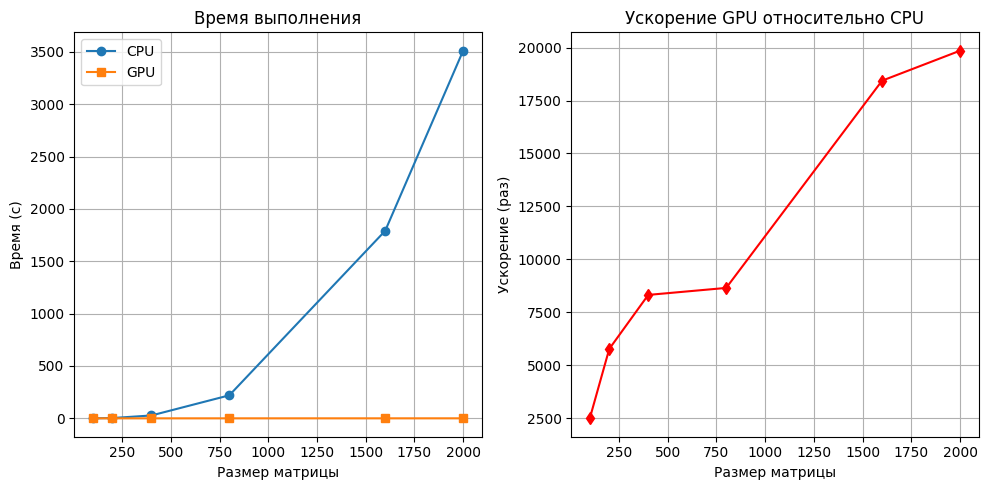

In [87]:
# После сбора результатов
sizes = [r['Размер'] for r in results]
cpu_times = [r['Время CPU'] for r in results]
gpu_times = [r['Время GPU'] for r in results]
speedups = [r['Ускорение'] for r in results]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(sizes, cpu_times, 'o-', label='CPU')
plt.plot(sizes, gpu_times, 's-', label='GPU')
plt.xlabel('Размер матрицы')
plt.ylabel('Время (с)')
plt.legend()
plt.grid(True)
plt.title('Время выполнения')

plt.subplot(1,2,2)
plt.plot(sizes, speedups, 'd-', color='red')
plt.xlabel('Размер матрицы')
plt.ylabel('Ускорение (раз)')
plt.grid(True)
plt.title('Ускорение GPU относительно CPU')

plt.tight_layout()
plt.savefig('matrix_mul_results.png', dpi=150)
plt.show()

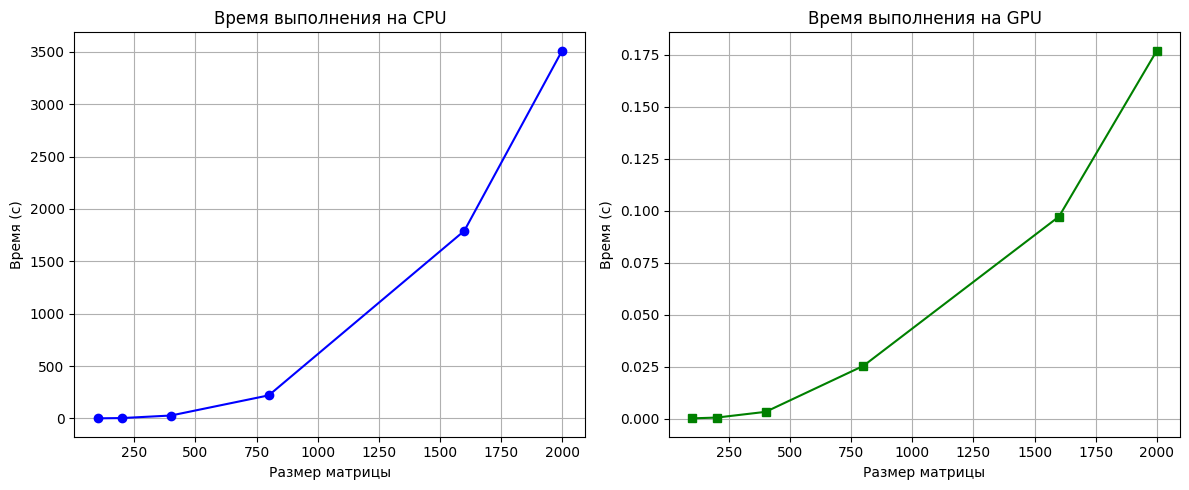

In [88]:
# Извлечение данных для графиков
sizes = [r['Размер'] for r in results]
cpu_times = [r['Время CPU'] for r in results]
gpu_times = [r['Время GPU'] for r in results]

# Построение графиков
plt.figure(figsize=(12, 5))

# График времени CPU
plt.subplot(1, 2, 1)
plt.plot(sizes, cpu_times, 'o-', color='blue', label='CPU')
plt.xlabel('Размер матрицы')
plt.ylabel('Время (с)')
plt.title('Время выполнения на CPU')
plt.grid(True)

# График времени GPU
plt.subplot(1, 2, 2)
plt.plot(sizes, gpu_times, 's-', color='green', label='GPU')
plt.xlabel('Размер матрицы')
plt.ylabel('Время (с)')
plt.title('Время выполнения на GPU')
plt.grid(True)

plt.tight_layout()
plt.show()
